In [142]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score


In [143]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


In [144]:
df = pd.read_csv("oil_seeds_punjab_agricultural_data.csv")


In [145]:
df.info

<bound method DataFrame.info of     Year  Crop_Name Crop_Type District_Name  Area_Hectares  Production_Tonnes  \
0   2020  Sunflower   Oilseed         Okara          12500              18750   
1   2020  Sunflower   Oilseed         Jhang          11200              16240   
2   2020  Sunflower   Oilseed    Faisalabad          15000              22500   
3   2020  Sunflower   Oilseed       Sahiwal           8900              11680   
4   2020  Sunflower   Oilseed    Gujranwala           7500               9750   
..   ...        ...       ...           ...            ...                ...   
73  2025  Rape Seed   Oilseed       Sialkot           5000               4000   
74  2025  Rape Seed   Oilseed        Gujrat           3500               2800   
75  2025       Gram     Pulse         Okara          11000              10450   
76  2025       Gram     Pulse         Kasur           9400               8930   
77  2025       Gram     Pulse       Sialkot           6700               5695

In [146]:
df.head(10)

,Year,Crop_Name,Crop_Type,District_Name,Area_Hectares,Production_Tonnes,Yield_Kg_Per_Hectare,Season,Temperature_Celsius_Avg,Rainfall_MM,Irrigation_Requirement_MM,Soil_Type,Market_Price_PKR_Per_Kg,Export_Status,Quality_Grade,Purity_Percent
0,2020,Sunflower,Oilseed,Okara,12500,18750,1500,Spring,32.5,425,250,Sandy Loam,65,Exported,A,96.2
1,2020,Sunflower,Oilseed,Jhang,11200,16240,1450,Spring,31.8,390,260,Loamy,63,Exported,A,95.8
2,2020,Sunflower,Oilseed,Faisalabad,15000,22500,1500,Spring,33.2,410,240,Sandy Loam,65,Exported,A,96.5
3,2020,Sunflower,Oilseed,Sahiwal,8900,11680,1312,Spring,32.1,380,270,Loamy,62,Local Market,B,94.2
4,2020,Sunflower,Oilseed,Gujranwala,7500,9750,1300,Spring,31.5,415,265,Clay Loam,60,Local Market,B,93.8
5,2020,Cotton Seed,Oilseed,Multan,22000,44000,2000,Summer,34.1,320,300,Clay Loam,45,Exported,A,97.5
6,2020,Cotton Seed,Oilseed,Bahawalpur,18500,37000,2000,Summer,35.2,280,320,Sandy,44,Exported,A,96.8
7,2020,Cotton Seed,Oilseed,Vehari,12300,24600,2000,Summer,34.8,310,310,Loamy,45,Local Market,B,95.5
8,2020,Rape Seed,Oilseed,Sialkot,3200,2560,800,Winter,18.2,650,150,Sandy Loam,120,Exported,A,98.2
9,2020,Rape Seed,Oilseed,Gujrat,2100,1680,800,Winter,17.9,620,160,Loamy,118,Local Market,B,96.8


In [147]:
df.tail(10)

,Year,Crop_Name,Crop_Type,District_Name,Area_Hectares,Production_Tonnes,Yield_Kg_Per_Hectare,Season,Temperature_Celsius_Avg,Rainfall_MM,Irrigation_Requirement_MM,Soil_Type,Market_Price_PKR_Per_Kg,Export_Status,Quality_Grade,Purity_Percent
68,2025,Sunflower,Oilseed,Sahiwal,11600,15080,1300,Spring,33.6,460,270,Loamy,93,Local Market,B,95.7
69,2025,Sunflower,Oilseed,Gujranwala,10000,13000,1300,Spring,33.0,495,265,Clay Loam,91,Local Market,B,95.3
70,2025,Cotton Seed,Oilseed,Multan,29500,59000,2000,Summer,35.6,410,300,Clay Loam,78,Exported,A,99.0
71,2025,Cotton Seed,Oilseed,Bahawalpur,25000,50000,2000,Summer,36.7,365,320,Sandy,74,Exported,A,98.3
72,2025,Cotton Seed,Oilseed,Vehari,17000,34000,2000,Summer,36.3,395,310,Loamy,76,Local Market,B,97.0
73,2025,Rape Seed,Oilseed,Sialkot,5000,4000,800,Winter,19.7,750,150,Sandy Loam,152,Exported,A,99.7
74,2025,Rape Seed,Oilseed,Gujrat,3500,2800,800,Winter,19.4,720,160,Loamy,148,Local Market,B,98.3
75,2025,Gram,Pulse,Okara,11000,10450,950,Winter,21.0,670,120,Sandy Loam,128,Exported,A,98.6
76,2025,Gram,Pulse,Kasur,9400,8930,950,Winter,21.3,680,110,Loamy,129,Exported,A,98.9
77,2025,Gram,Pulse,Sialkot,6700,5695,850,Winter,18.7,730,100,Clay Loam,124,Local Market,B,97.1


In [148]:
df.shape

(78, 16)

In [149]:
df.describe()

,Year,Area_Hectares,Production_Tonnes,Yield_Kg_Per_Hectare,Temperature_Celsius_Avg,Rainfall_MM,Irrigation_Requirement_MM,Market_Price_PKR_Per_Kg,Purity_Percent
count,78.000000,78.000000,78.000000,78.000000,78.000000,78.000000,78.000000,78.000000,78.000000
mean,2022.500000,12116.666667,18833.205128,1338.615385,28.273077,510.320513,219.615385,90.679487,97.011538
std,1.718879,6750.688597,15350.553334,441.423825,7.283047,135.743120,77.420966,27.957061,1.335332
min,2020.000000,2100.000000,1680.000000,800.000000,17.200000,280.000000,100.000000,44.000000,93.800000
25%,2021.000000,7575.000000,7505.000000,950.000000,19.800000,402.500000,150.000000,68.500000,96.200000
50%,2022.500000,10900.000000,13650.000000,1300.000000,32.450000,470.000000,250.000000,86.000000,97.100000
75%,2024.000000,15575.000000,26625.000000,1500.000000,34.100000,650.000000,270.000000,114.250000,98.000000
max,2025.000000,29500.000000,59000.000000,2000.000000,36.700000,750.000000,320.000000,152.000000,99.700000


In [150]:
df.isnull()

,Year,Crop_Name,Crop_Type,District_Name,Area_Hectares,Production_Tonnes,Yield_Kg_Per_Hectare,Season,Temperature_Celsius_Avg,Rainfall_MM,Irrigation_Requirement_MM,Soil_Type,Market_Price_PKR_Per_Kg,Export_Status,Quality_Grade,Purity_Percent
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
74,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
75,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
76,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [151]:
df.dropna()

,Year,Crop_Name,Crop_Type,District_Name,Area_Hectares,Production_Tonnes,Yield_Kg_Per_Hectare,Season,Temperature_Celsius_Avg,Rainfall_MM,Irrigation_Requirement_MM,Soil_Type,Market_Price_PKR_Per_Kg,Export_Status,Quality_Grade,Purity_Percent
0,2020,Sunflower,Oilseed,Okara,12500,18750,1500,Spring,32.5,425,250,Sandy Loam,65,Exported,A,96.2
1,2020,Sunflower,Oilseed,Jhang,11200,16240,1450,Spring,31.8,390,260,Loamy,63,Exported,A,95.8
2,2020,Sunflower,Oilseed,Faisalabad,15000,22500,1500,Spring,33.2,410,240,Sandy Loam,65,Exported,A,96.5
3,2020,Sunflower,Oilseed,Sahiwal,8900,11680,1312,Spring,32.1,380,270,Loamy,62,Local Market,B,94.2
4,2020,Sunflower,Oilseed,Gujranwala,7500,9750,1300,Spring,31.5,415,265,Clay Loam,60,Local Market,B,93.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73,2025,Rape Seed,Oilseed,Sialkot,5000,4000,800,Winter,19.7,750,150,Sandy Loam,152,Exported,A,99.7
74,2025,Rape Seed,Oilseed,Gujrat,3500,2800,800,Winter,19.4,720,160,Loamy,148,Local Market,B,98.3
75,2025,Gram,Pulse,Okara,11000,10450,950,Winter,21.0,670,120,Sandy Loam,128,Exported,A,98.6
76,2025,Gram,Pulse,Kasur,9400,8930,950,Winter,21.3,680,110,Loamy,129,Exported,A,98.9


In [152]:
df.dtypes

Year                           int64
Crop_Name                     object
Crop_Type                     object
District_Name                 object
Area_Hectares                  int64
Production_Tonnes              int64
Yield_Kg_Per_Hectare           int64
Season                        object
Temperature_Celsius_Avg      float64
Rainfall_MM                    int64
Irrigation_Requirement_MM      int64
Soil_Type                     object
Market_Price_PKR_Per_Kg        int64
Export_Status                 object
Quality_Grade                 object
Purity_Percent               float64
dtype: object

In [153]:
df['Area_Hectares'] = df['Area_Hectares'].fillna(df['Area_Hectares'].mean())

In [154]:
df.duplicated().sum()

np.int64(0)

In [155]:
df.columns = df.columns.str.strip()

In [156]:
df['Crop_Name'] = df['Crop_Name'].str.strip()

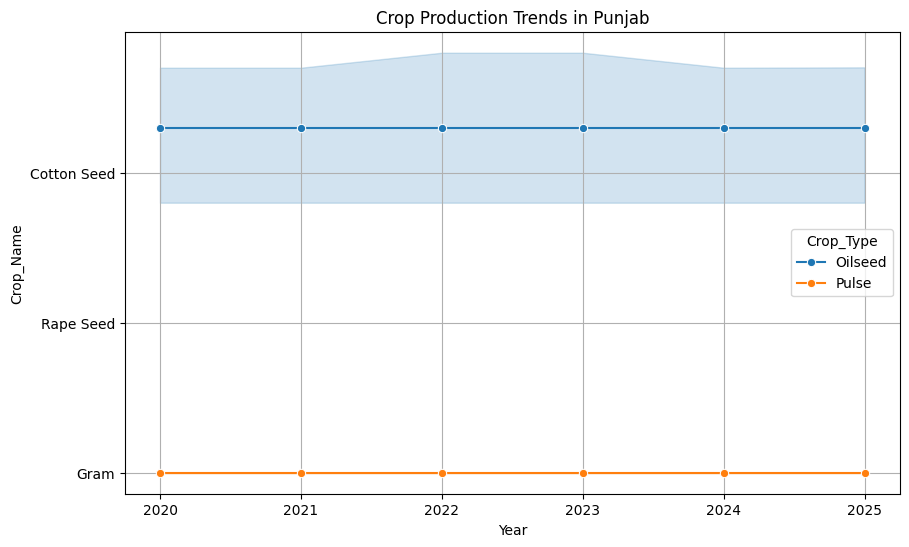

In [157]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x='Year', y='Crop_Name', hue='Crop_Type', marker='o')
plt.title('Crop Production Trends in Punjab')
plt.grid(True)
plt.show()

In [158]:
def show_fig():
    plt.tight_layout()
    plt.show()


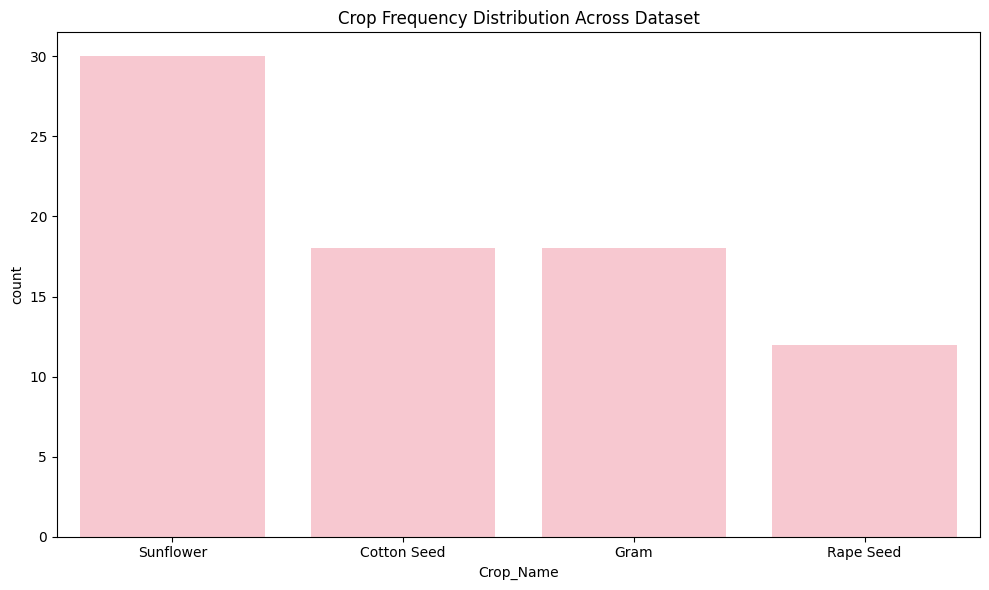

In [159]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Crop_Name', order=df['Crop_Name'].value_counts().index, color = 'Pink')
plt.title('Crop Frequency Distribution Across Dataset')
show_fig()


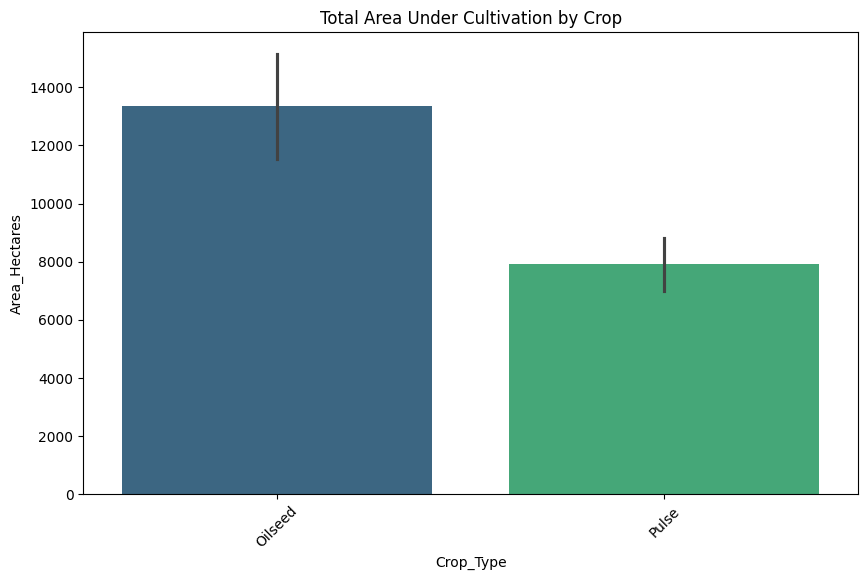

In [160]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='Crop_Type', y='Area_Hectares', palette='viridis')
plt.title('Total Area Under Cultivation by Crop')
plt.xticks(rotation=45)
plt.show()


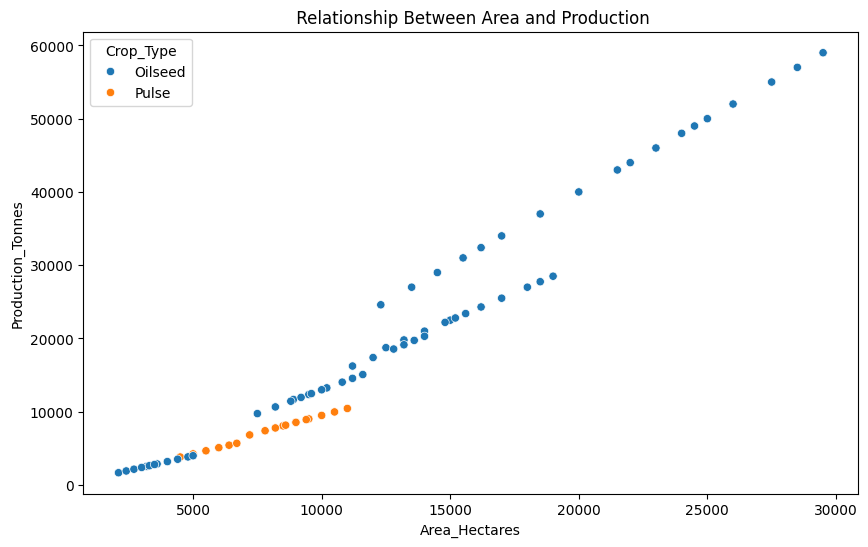

In [161]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Area_Hectares', y='Production_Tonnes', hue='Crop_Type')
plt.title(' Relationship Between Area and Production')
plt.show()



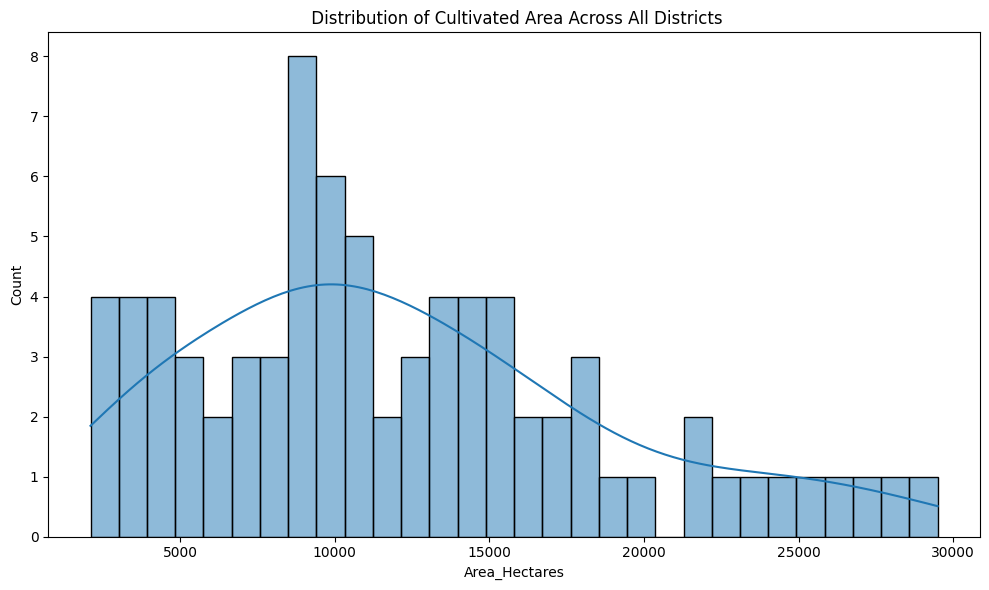

In [162]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['Area_Hectares'], bins=30, kde=True)
plt.title(' Distribution of Cultivated Area Across All Districts')
show_fig()

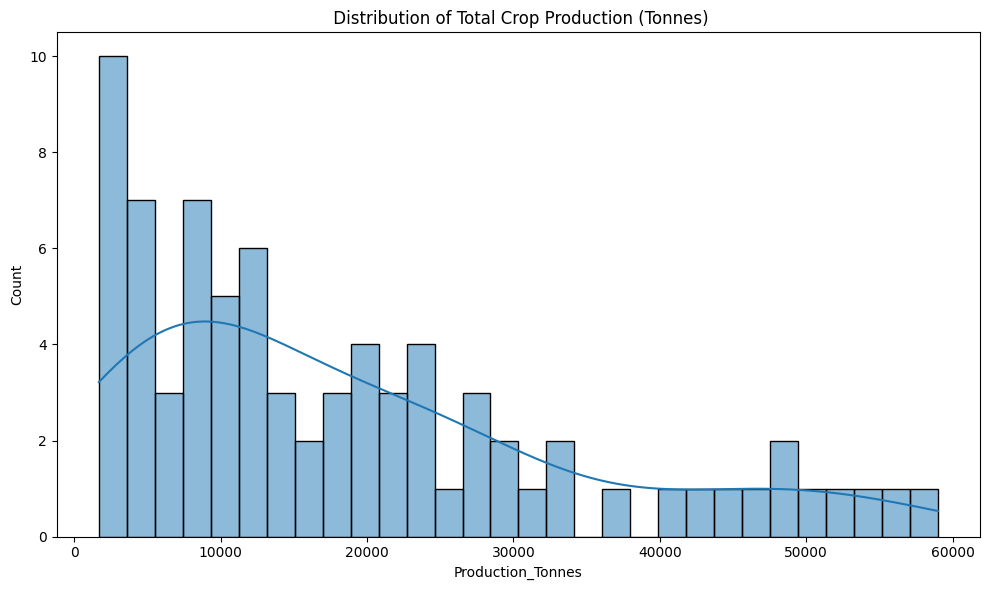

In [163]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['Production_Tonnes'], bins=30, kde=True)
plt.title(' Distribution of Total Crop Production (Tonnes)')
show_fig()


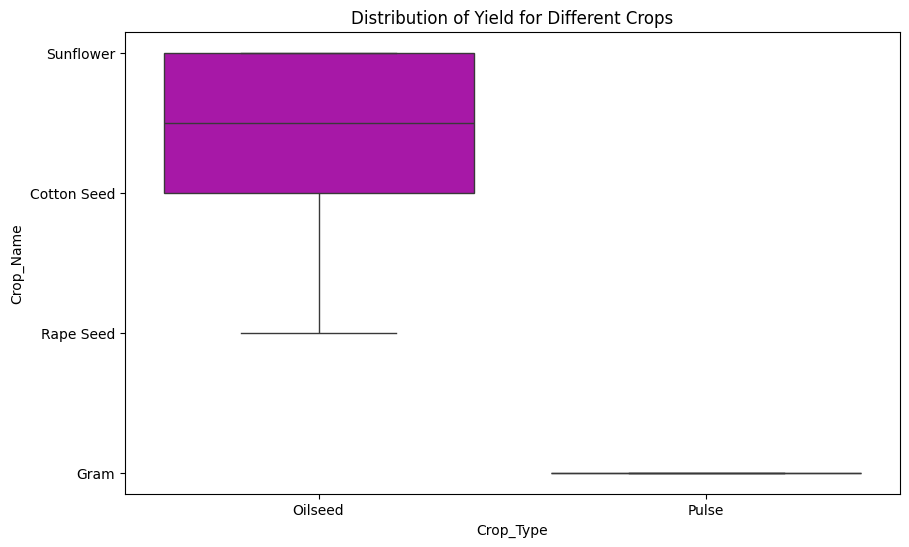

In [164]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Crop_Type', y='Crop_Name', color = 'm')
plt.title('Distribution of Yield for Different Crops')
plt.show()


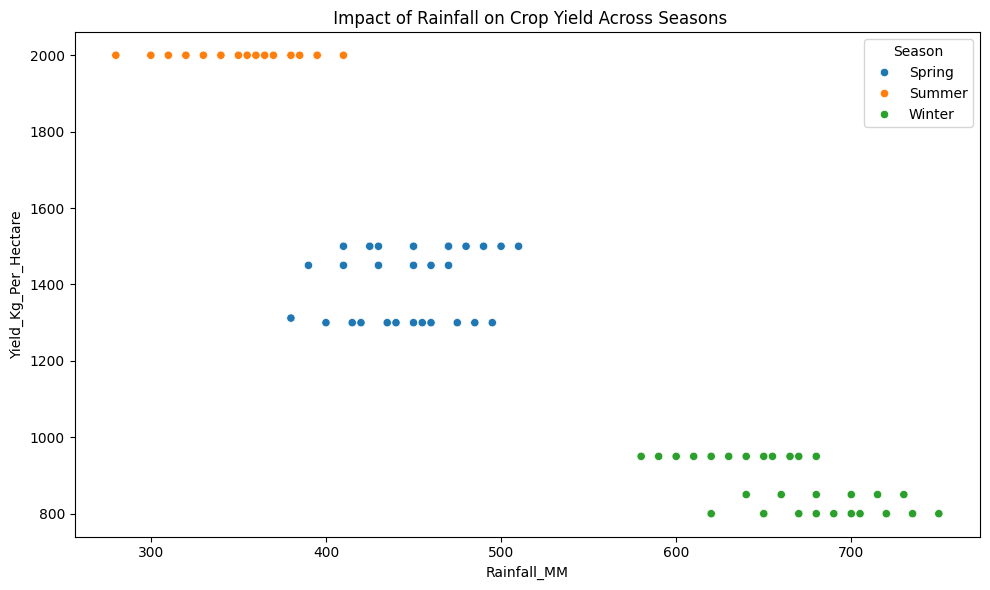

In [165]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Rainfall_MM', y='Yield_Kg_Per_Hectare', hue='Season')
plt.title(' Impact of Rainfall on Crop Yield Across Seasons')
show_fig()


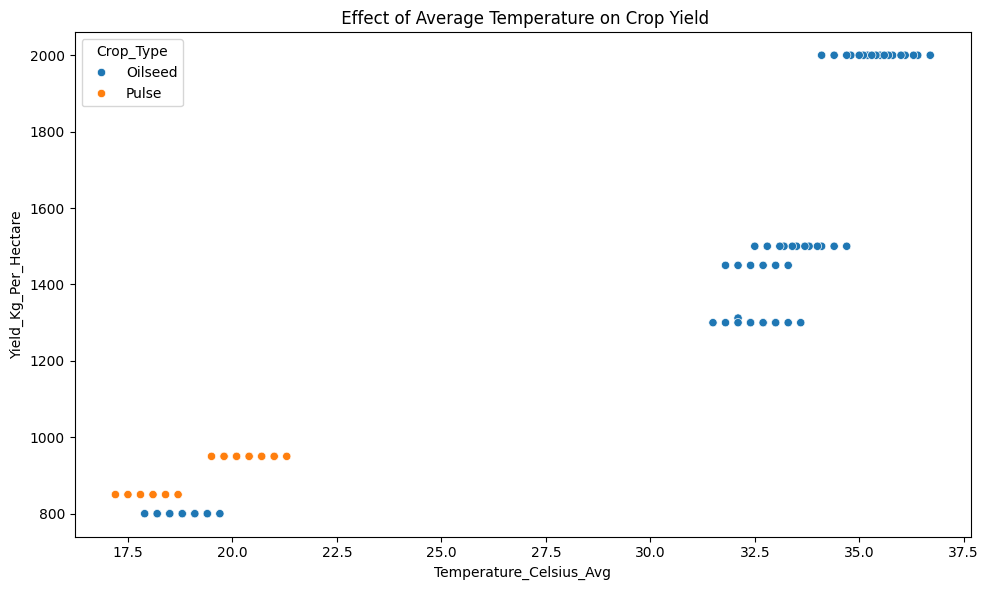

In [166]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Temperature_Celsius_Avg', y='Yield_Kg_Per_Hectare', hue='Crop_Type')
plt.title(' Effect of Average Temperature on Crop Yield')
show_fig()


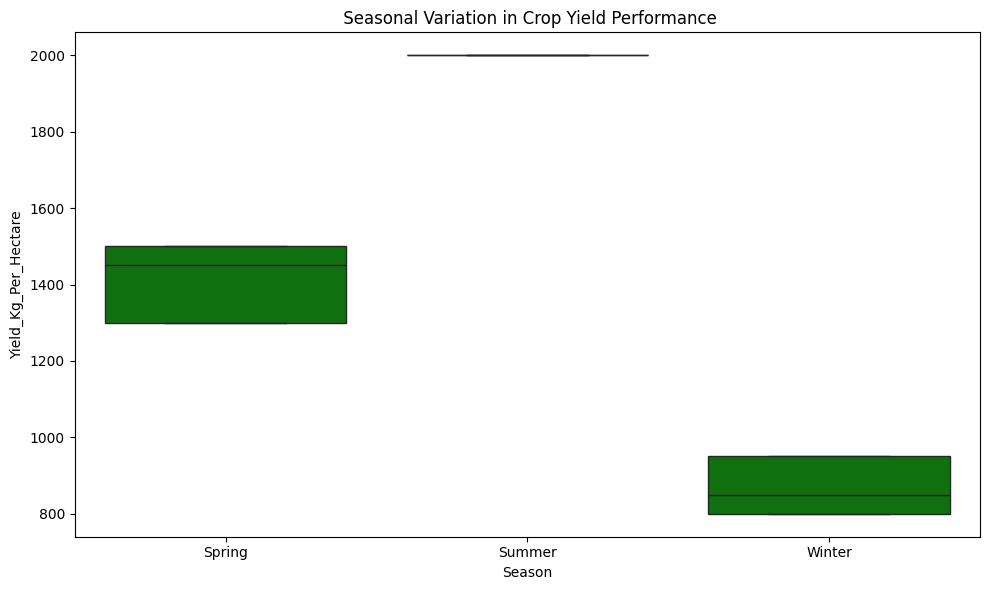

In [167]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Season', y='Yield_Kg_Per_Hectare',color = 'g')
plt.title(' Seasonal Variation in Crop Yield Performance')
show_fig()

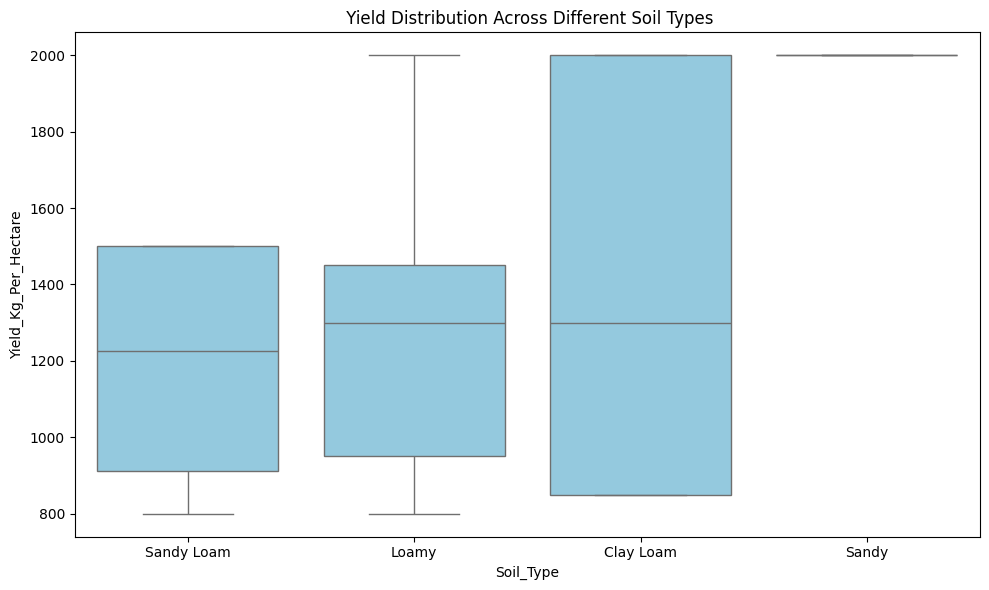

In [168]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Soil_Type', y='Yield_Kg_Per_Hectare', color = 'skyblue')
plt.title(' Yield Distribution Across Different Soil Types')
show_fig()

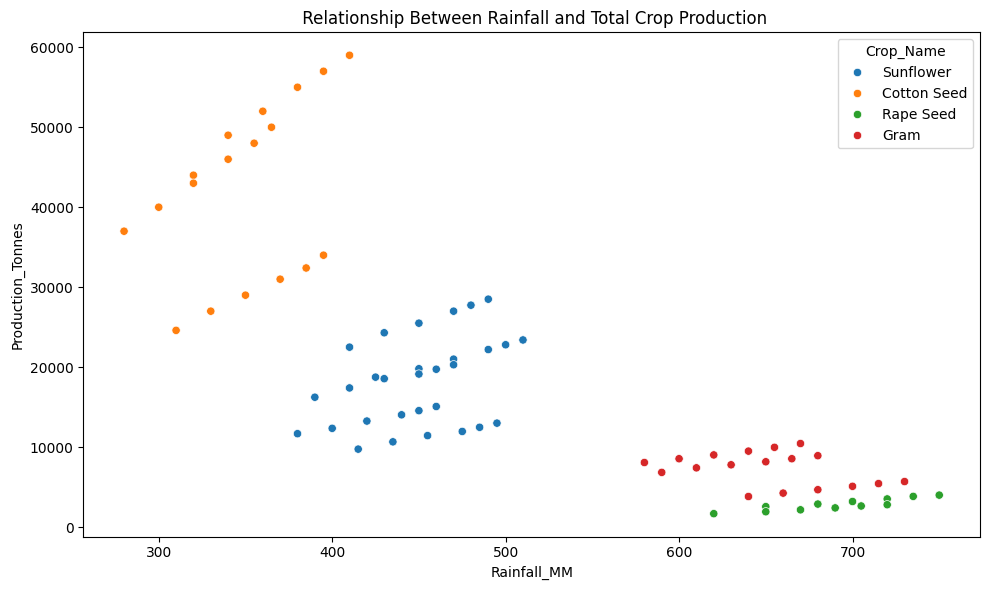

In [169]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Rainfall_MM', y='Production_Tonnes', hue='Crop_Name')
plt.title(' Relationship Between Rainfall and Total Crop Production')
show_fig()

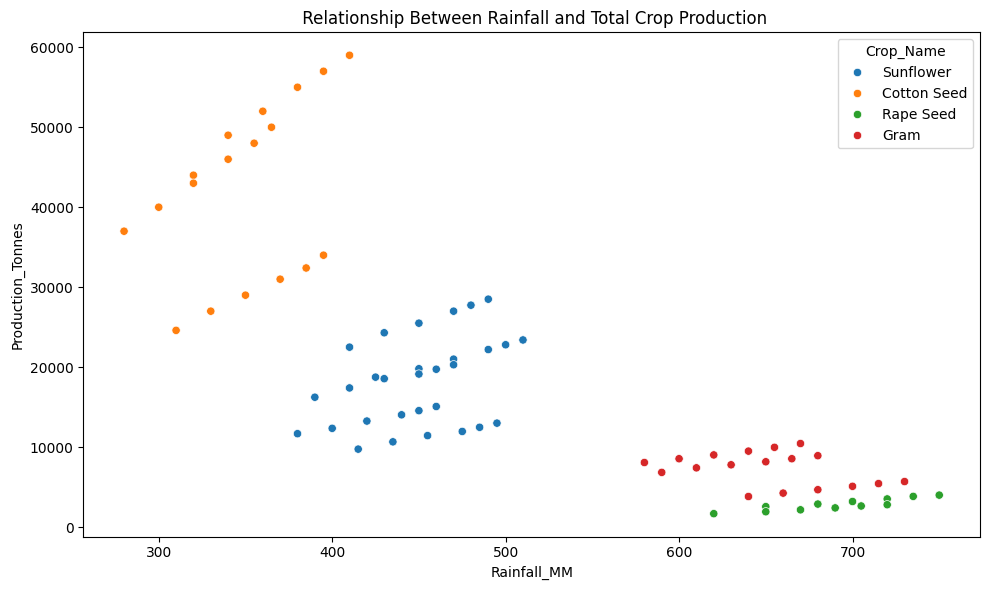

In [170]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Rainfall_MM', y='Production_Tonnes', hue='Crop_Name')
plt.title(' Relationship Between Rainfall and Total Crop Production')
show_fig()

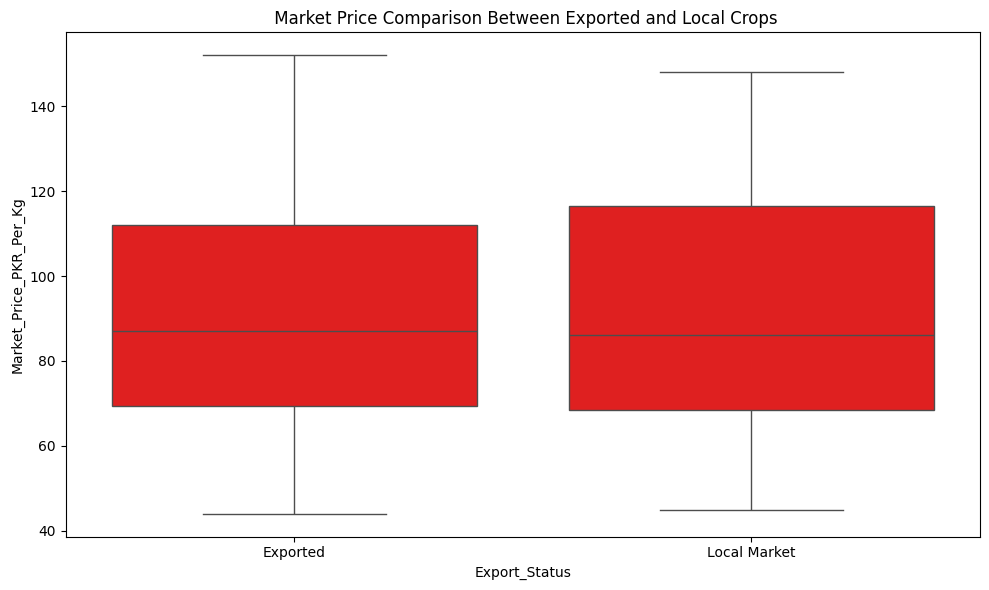

In [171]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Export_Status', y='Market_Price_PKR_Per_Kg', color = 'Red')
plt.title(' Market Price Comparison Between Exported and Local Crops')
show_fig()

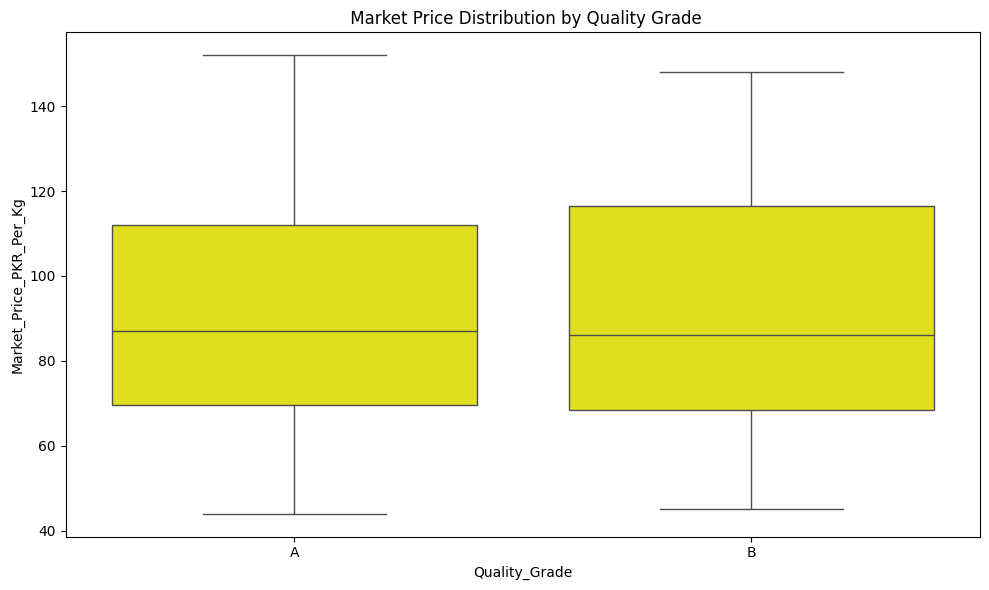

In [172]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Quality_Grade', y='Market_Price_PKR_Per_Kg', color = 'yellow')
plt.title(' Market Price Distribution by Quality Grade')
show_fig()

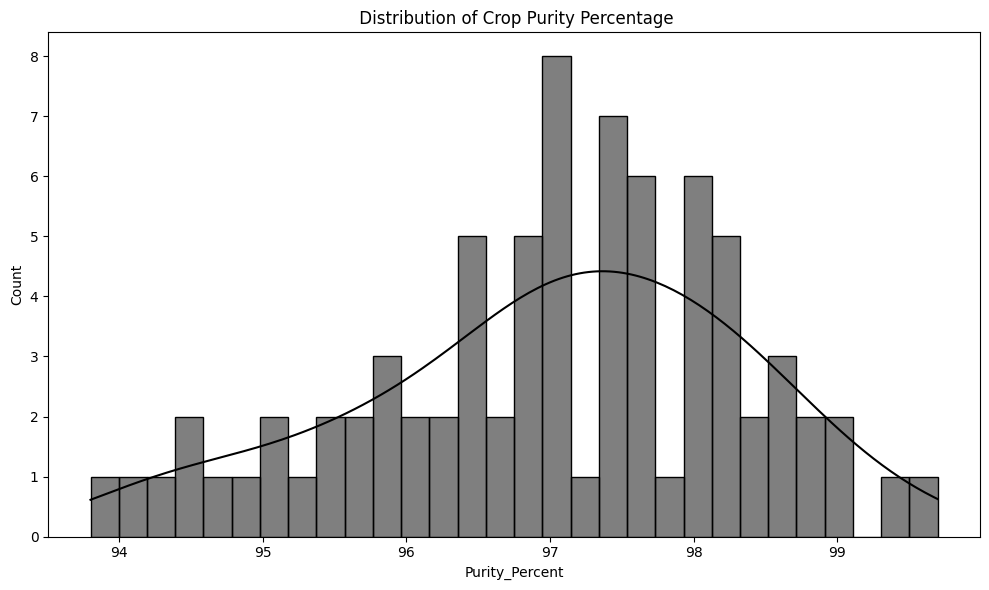

In [173]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['Purity_Percent'], bins=30, kde=True, color = 'Black')
plt.title(' Distribution of Crop Purity Percentage')
show_fig()

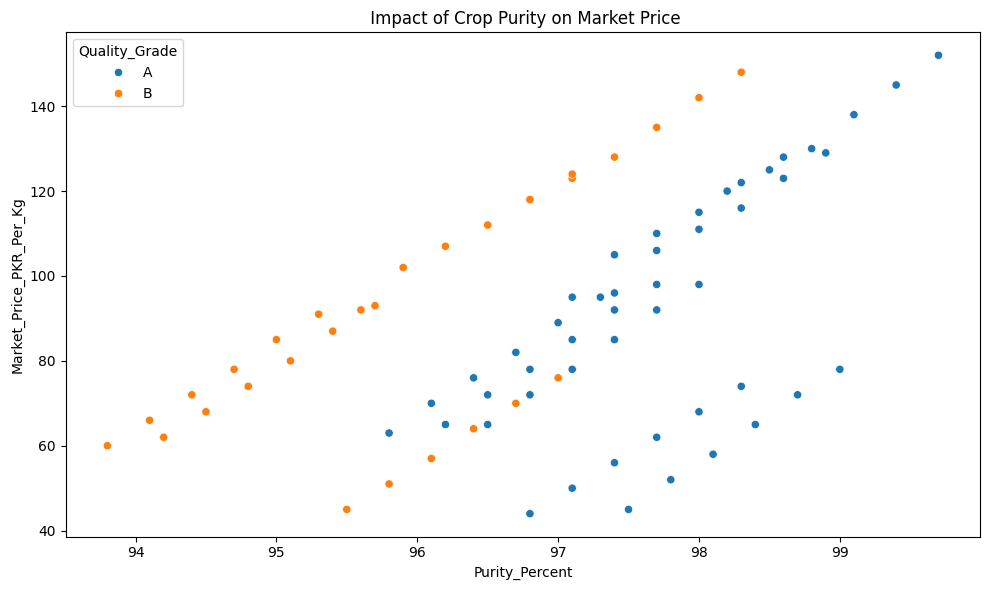

In [174]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Purity_Percent', y='Market_Price_PKR_Per_Kg', hue='Quality_Grade')
plt.title(' Impact of Crop Purity on Market Price')
show_fig()

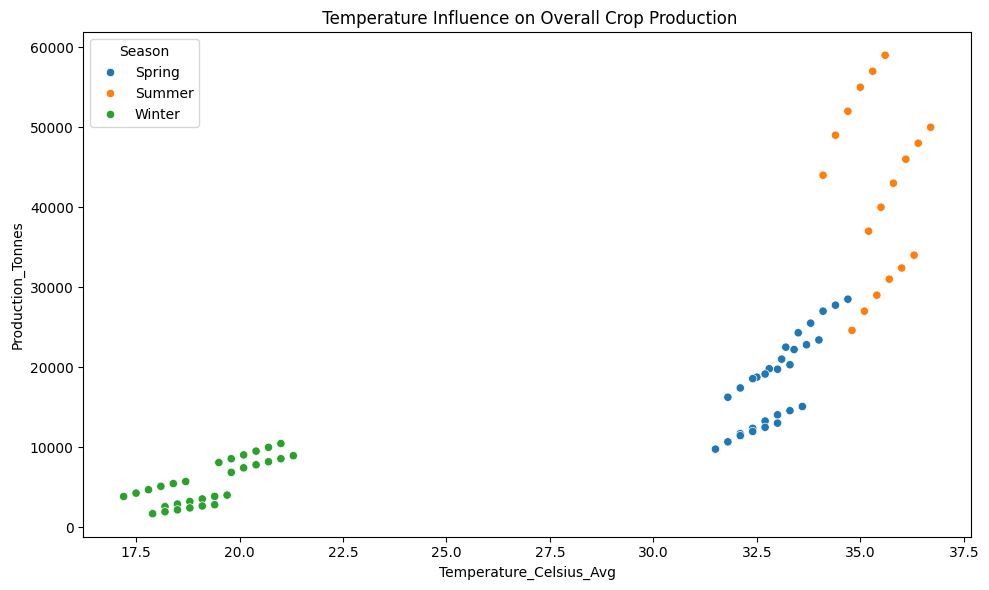

In [175]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Temperature_Celsius_Avg', y='Production_Tonnes', hue='Season')
plt.title(' Temperature Influence on Overall Crop Production')
show_fig()

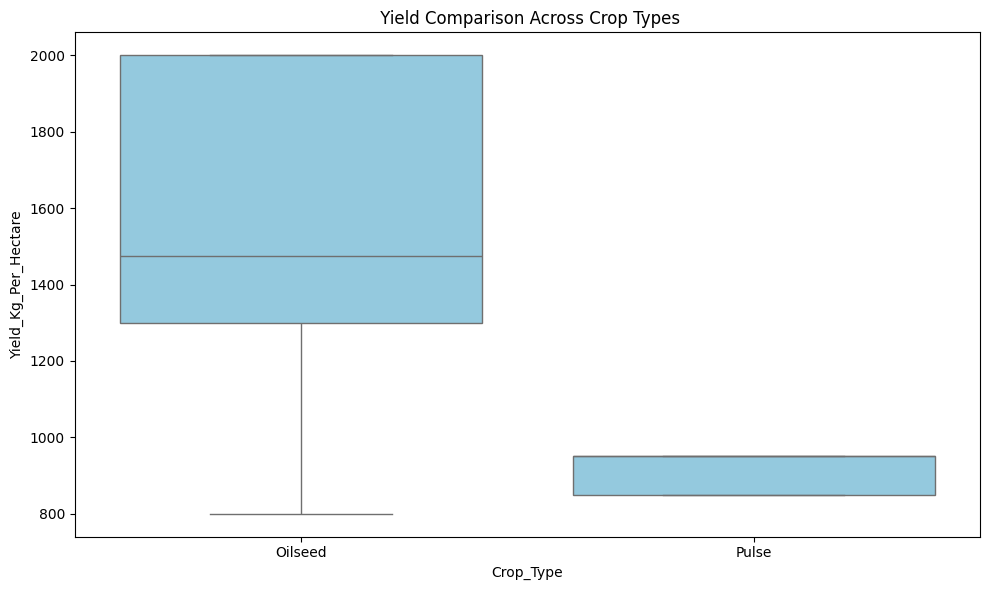

In [176]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Crop_Type', y='Yield_Kg_Per_Hectare', color = 'Skyblue')
plt.title(' Yield Comparison Across Crop Types')
show_fig()

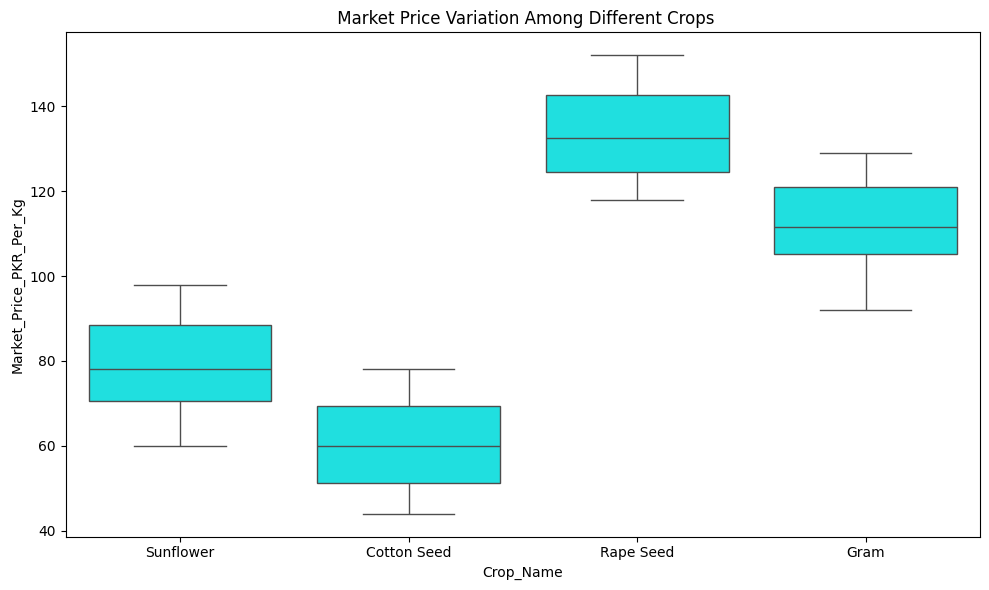

In [177]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Crop_Name', y='Market_Price_PKR_Per_Kg', color = 'cyan')
plt.title(' Market Price Variation Among Different Crops')
show_fig()


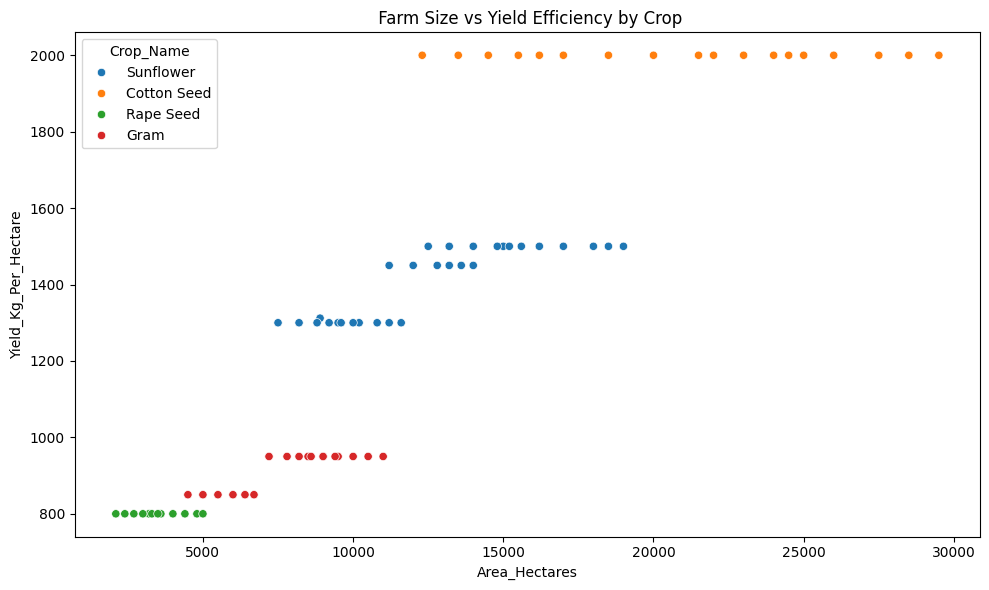

In [178]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Area_Hectares', y='Yield_Kg_Per_Hectare', hue='Crop_Name', color = 'magenta')
plt.title(' Farm Size vs Yield Efficiency by Crop')
show_fig()

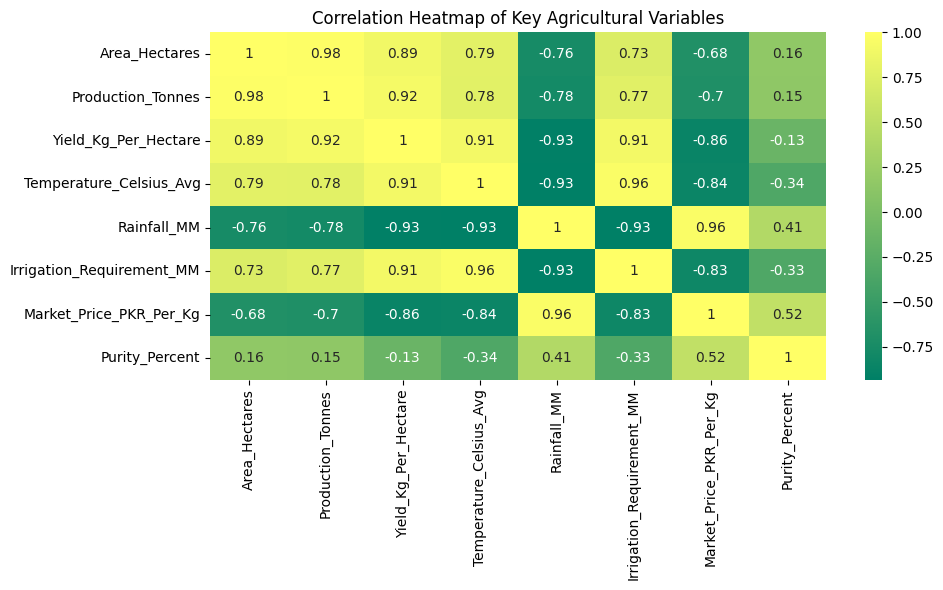

In [179]:
fig = plt.figure(figsize=(10,6))
corr = df[['Area_Hectares','Production_Tonnes','Yield_Kg_Per_Hectare','Temperature_Celsius_Avg','Rainfall_MM','Irrigation_Requirement_MM','Market_Price_PKR_Per_Kg','Purity_Percent']].corr()
sns.heatmap(corr, annot=True, cmap='summer')
plt.title('Correlation Heatmap of Key Agricultural Variables')
show_fig()

In [180]:
X = df.drop(['Yield_Kg_Per_Hectare', 'Production_Tonnes'], axis=1) 
y = df['Yield_Kg_Per_Hectare']

In [181]:

X_encoded = pd.get_dummies(X, drop_first=True)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)


RandomForestRegressor(random_state=42)

In [182]:
from sklearn.metrics import mean_absolute_error, r2_score
y_pred = model.predict(X_test)
print(f"R-squared Score: {r2_score(y_test, y_pred):.2f}")
print(f"Mean Absolute Error: {mean_absolute_error(y_test, y_pred):.2f}")


R-squared Score: 1.00
Mean Absolute Error: 12.93


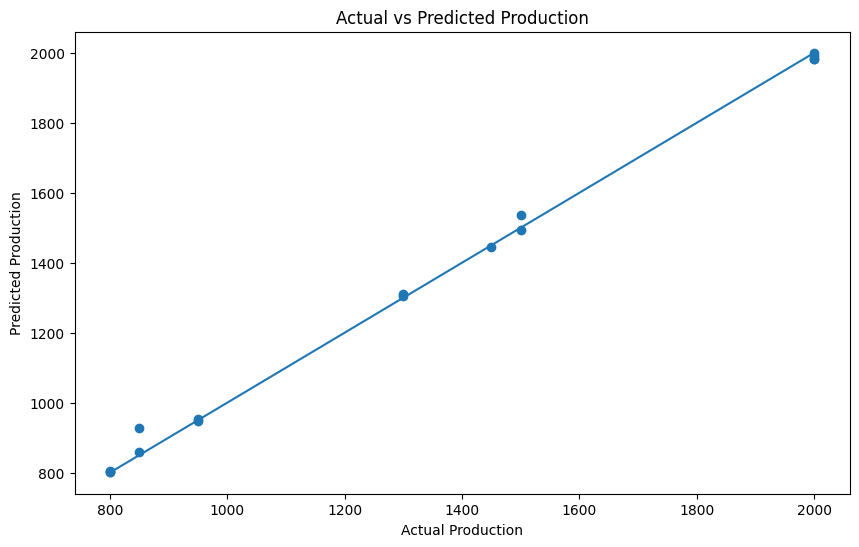

In [183]:
plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Production")
plt.ylabel("Predicted Production")
plt.title("Actual vs Predicted Production")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.show()

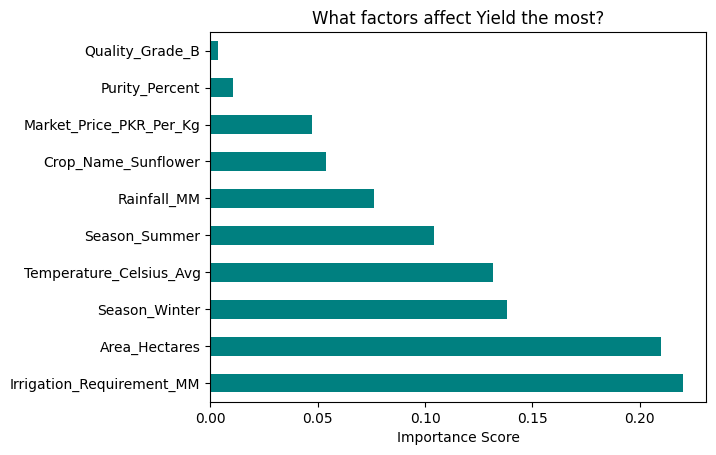

In [184]:
import matplotlib.pyplot as plt
import pandas as pd
importances = pd.Series(model.feature_importances_, index=X_encoded.columns)
importances.nlargest(10).plot(kind='barh', color='teal')
plt.title('What factors affect Yield the most?')
plt.xlabel('Importance Score')
plt.show()


In [185]:
new_scenario = { 'Year': 2025, 'Area': 100, 'Soil_Type': 'Silt', 'Crop_Type': 'Cotton Seed'}
input_df = pd.DataFrame([new_scenario])
input_encoded = pd.get_dummies(input_df)
input_encoded = input_encoded.reindex(columns=X_encoded.columns, fill_value=0)

In [186]:
predicted_yield = model.predict(input_encoded)
print(f"--- PREDICTION RESULT ---")
print(f"Predicted Yield: {predicted_yield[0]:.2f} kg per hectare")


--- PREDICTION RESULT ---
Predicted Yield: 1201.80 kg per hectare
